## **Data cleaning for the Subjective Opioid Withdrawal symptoms**

### *Clinical Trial CTN-0051: Extended-Release Naltroxone vs. Buprenorphine for Opioid Treatment*

The SOWS is a questionnaire administered at every visit throughout the trial. It asks the participant to rate 14 withdrawal symptoms on a scale of 0 (none) to 4 (severe).

**Visit schedule note:** The protocol has 9 scheduled numeric visits: weeks 1, 2, 3, 4, 8, 12, 16, 20, 24. Supplemental visits (e.g. `08S`, `06S`) are suffixed with letters and must be excluded. The VISNO column contains a mix of numeric strings (`'01'`–`'24'`), supplemental strings (`'08S'`, `'06T'`), induction sub-visits (`'00R'`, `'00RS'`), and follow-up labels (`'EOT'`, `'M1FU'`, `'M3FU'`). We keep only the 9 scheduled protocol weeks.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Load SOWS ─────────────────────────────────────────────────────────────────
sow_raw = pd.read_excel("../../raw-data/AE.xlsx", sheet_name="sow.csv")

print(f"Shape: {sow_raw.shape}")
print(f"Unique patients: {sow_raw['PATID'].nunique()}")
print(f"\nPROTSEG distribution:\n{sow_raw['PROTSEG'].value_counts().to_string()}")
print(f"\nVISNO distribution:\n{sow_raw['VISNO'].value_counts().sort_index().to_string()}")
print(f"\nColumns:\n{sow_raw.columns.tolist()}")
print(f"\nHead:")
sow_raw.head(3)

Shape: (6095, 25)
Unique patients: 635

PROTSEG distribution:
PROTSEG
B    5460
A     635

VISNO distribution:
VISNO
00      635
00R     484
00RS    473
00RT    243
00RU     42
00RV     26
00RW     13
00RX      2
00RY      1
00RZ      1
01      466
01S       1
02      422
02S       1
03      422
03S       1
04      407
04S       4
05        1
06        2
06S       2
06T       1
07        1
08      326
08S       8
08T       2
09        2
09S       1
10        2
10S       1
11        2
11S       1
12      263
12S       2
14        2
14S       3
14T       1
16      241
16S       5
16T       1
17        1
17S       1
18        2
19S       2
20      219
20S       2
20T       1
21        2
21S       1
22        2
22S       1
24      368
EOT     180
M1FU    369
M3FU    430

Columns:
['PROT', 'PATID', 'SITE', 'RANDDT', 'PROTSEG', 'VISNO', 'SOWASMDT', 'SOASMTM', 'SOANX', 'SOYAWN', 'SOSWEAT', 'SOOUTEAR', 'SONOSRUN', 'SOGOSBUM', 'SOSHAKE', 'SOHOT', 'SOCOLD', 'SOACHE', 'SORESTLS', 'SONAUS', 'SOVOM

,PROT,PATID,SITE,RANDDT,PROTSEG,VISNO,SOWASMDT,SOASMTM,SOANX,SOYAWN,...,SOHOT,SOCOLD,SOACHE,SORESTLS,SONAUS,SOVOMIT,SOMUSTWT,SOSCHCMP,SOUSENOW,SOWCOMM
0,51,948442,NaN,0.0,B,M1FU,201.0,13:56,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
1,51,948442,NaN,0.0,B,24,189.0,13:35,2.0,1.0,...,0.0,0.0,2.0,0.0,2.0,2.0,0.0,0.0,2.0,NaN
2,51,948442,NaN,0.0,B,20,137.0,10:31,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN


In [34]:
# ── SOWS item columns and rename map ─────────────────────────────────────────
sow_rename = {
    'SOANX'   : 'anxiety',
    'SOYAWN'  : 'yawning',
    'SOSWEAT' : 'sweating',
    'SOOUTEAR': 'tearing',
    'SONOSRUN': 'runny_nose',
    'SOGOSBUM': 'goosebumps',
    'SOSHAKE' : 'shaking',
    'SOHOT'   : 'hot_flushes',
    'SOCOLD'  : 'chills',
    'SOACHE'  : 'aches',
    'SORESTLS': 'restlessness',
    'SONAUS'  : 'nausea',
    'SOVOMIT' : 'vomiting',
    'SOMUSTWT': 'muscle_twitching',
}
item_cols_renamed = list(sow_rename.values())

In [35]:
# ── Define scheduled protocol weeks ──────────────────────────────────────────
# Strategy: keep only VISNO strings that are purely numeric (no letter suffix)
# AND map to one of the 9 protocol-scheduled visit weeks.
#
# Rationale from coverage analysis:
#   - Weeks 1,2,3,4,8,12,16,20,24 have ≥34% patient coverage → scheduled visits
#   - Weeks 5,6,7,9,10,11,14,17,18,21,22 have ≤3 patients   → supplemental only
#     (these sneak through when e.g. '05' is parsed but '05S' is the real visit)
#
# Filter 1: VISNO must be a purely numeric string (no letters after digits)
# Filter 2: the resulting integer must be in SCHEDULED_WEEKS

SCHEDULED_WEEKS = [1, 2, 3, 4, 8, 12, 16, 20, 24]

def is_scheduled_visit(visno):
    """Return True only for purely numeric VISNO strings that are scheduled weeks."""
    try:
        week = int(visno)          # fails on '08S', 'M1FU', 'EOT', '00R' etc.
        return week in SCHEDULED_WEEKS
    except (ValueError, TypeError):
        return False

# Apply filter
sow_raw['is_scheduled'] = sow_raw['VISNO'].apply(is_scheduled_visit)

print("Rows per VISNO category:")
print(f"  Week 0 (baseline, VISNO='00')      : {(sow_raw['VISNO']=='00').sum()}")
print(f"  Scheduled treatment visits (wk 1–24): {sow_raw['is_scheduled'].sum()}")
print(f"  Other (induction, supplemental, FU) : {(~sow_raw['is_scheduled'] & (sow_raw['VISNO']!='00')).sum()}")

Rows per VISNO category:
  Week 0 (baseline, VISNO='00')      : 635
  Scheduled treatment visits (wk 1–24): 3134
  Other (induction, supplemental, FU) : 2326


In [36]:
# ── Build clean working dataframe ─────────────────────────────────────────────
sow = sow_raw.copy()
sow = sow.rename(columns=sow_rename)
sow['week'] = sow['VISNO'].apply(
    lambda v: int(v) if is_scheduled_visit(v) or v == '00' else np.nan
)

# Keep only week-0 (baseline) and scheduled treatment weeks
sow = sow[sow['week'].notna()].copy()
sow['week'] = sow['week'].astype(int)
sow = sow[['PATID', 'week', 'PROTSEG'] + item_cols_renamed].copy()

print(f"Rows kept (week 0 + scheduled treatment weeks): {len(sow)}")
print(f"Unique patients: {sow['PATID'].nunique()}")
print(f"\nWeek distribution:")
print(sow['week'].value_counts().sort_index().to_string())
print(f"\nMissing values per SOWS item:")
print(sow[item_cols_renamed].isnull().sum().to_string())

Rows kept (week 0 + scheduled treatment weeks): 3769
Unique patients: 635

Week distribution:
week
0     635
1     466
2     422
3     422
4     407
8     326
12    263
16    241
20    219
24    368

Missing values per SOWS item:
anxiety             0
yawning             1
sweating            0
tearing             1
runny_nose          0
goosebumps          0
shaking             0
hot_flushes         0
chills              0
aches               1
restlessness        0
nausea              0
vomiting            0
muscle_twitching    0


In [37]:
# ── Separate baseline (week 0) and treatment weeks ────────────────────────────
sow_baseline  = sow[sow['week'] == 0].copy()
sow_treatment = sow[sow['week'] >  0].copy()

print(f"Baseline  (week 0)           : {len(sow_baseline)} rows, "
      f"{sow_baseline['PATID'].nunique()} patients")
print(f"Treatment (scheduled wk 1–24): {len(sow_treatment)} rows, "
      f"{sow_treatment['PATID'].nunique()} patients")

# Coverage per scheduled week
coverage = (
    sow_treatment.groupby('week')['PATID']
    .count()
    .reset_index()
    .rename(columns={'PATID': 'n_patients'})
    .assign(pct=lambda d: (d['n_patients'] / sow['PATID'].nunique() * 100).round(1))
)
print(f"\nPatient coverage by scheduled week:")
print(coverage.to_string(index=False))

Baseline  (week 0)           : 635 rows, 635 patients
Treatment (scheduled wk 1–24): 3134 rows, 518 patients

Patient coverage by scheduled week:
 week  n_patients  pct
    1         466 73.4
    2         422 66.5
    3         422 66.5
    4         407 64.1
    8         326 51.3
   12         263 41.4
   16         241 38.0
   20         219 34.5
   24         368 58.0


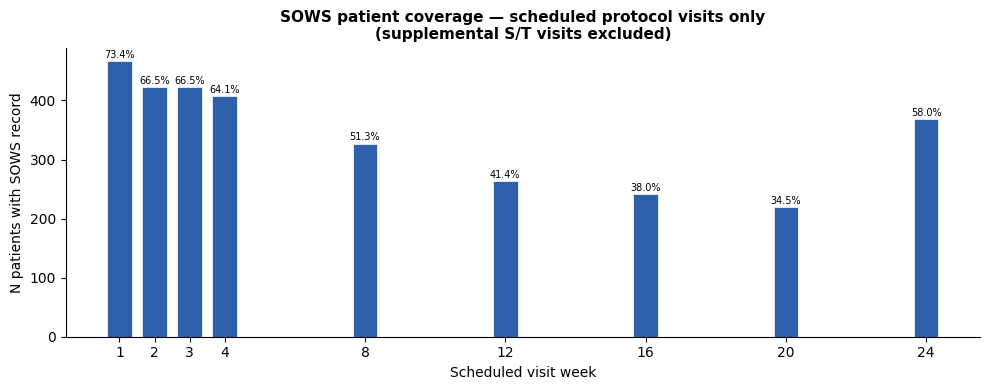

In [38]:
# ── Coverage plot ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(coverage['week'], coverage['n_patients'],
       color='#2E5FAC', edgecolor='white', linewidth=0.5,
       width=0.7)
for _, row in coverage.iterrows():
    ax.text(row['week'], row['n_patients'] + 3,
            f"{row['pct']}%", ha='center', va='bottom', fontsize=7)
ax.set_xticks(SCHEDULED_WEEKS)
ax.set_xlabel('Scheduled visit week', fontsize=10)
ax.set_ylabel('N patients with SOWS record', fontsize=10)
ax.set_title('SOWS patient coverage — scheduled protocol visits only\n'
             '(supplemental S/T visits excluded)',
             fontsize=11, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()

---
## Feature extraction

### A. Baseline SOWS (week 0) — merge into pre-trial.csv

In [39]:
# ── A. Baseline SOWS (week 0) — one row per patient ──────────────────────────
sow_bl_features = (
    sow_baseline
    .drop_duplicates(subset='PATID', keep='first')
    [['PATID'] + item_cols_renamed]
    .rename(columns={c: f'sow_{c}_baseline' for c in item_cols_renamed})
)

# Add total baseline withdrawal score
sow_bl_cols = [f'sow_{c}_baseline' for c in item_cols_renamed]
sow_bl_features['sow_total_baseline'] = sow_bl_features[sow_bl_cols].sum(axis=1)

# Merge into pre-trial
baseline  = pd.read_csv("../../clean-data/pre-trial.csv")
pre_trial = baseline.merge(sow_bl_features, on='PATID', how='inner')

print(f"Baseline SOWS features : {sow_bl_features.shape}")
print(f"pre-trial before merge : {baseline.shape}")
print(f"pre-trial after  merge : {pre_trial.shape}")
print(f"\nPre-trial saved → ../../clean-data/pre-trial.csv")
pre_trial.to_csv("../../clean-data/pre-trial.csv", index=False)

Baseline SOWS features : (635, 16)
pre-trial before merge : (569, 70)
pre-trial after  merge : (569, 85)

Pre-trial saved → ../../clean-data/pre-trial.csv


### B. Early-window summary features (weeks 1–4)

Mean and OLS slope per item over the **first 4 scheduled visits** (weeks 1, 2, 3, 4). These are the visits with highest coverage (64–73%) and occur before the main dropout wave at week 8. The slope captures whether withdrawal was improving or worsening early in treatment.

In [40]:
# ── B. Early-window summary (weeks 1–4 — highest coverage window) ─────────────
# Using only weeks 1–4 (all scheduled, all >64% coverage)
# Week 8 is excluded from the 'early' window since it already shows
# substantial dropout and would introduce survivorship bias in the slope

EARLY_WEEKS = [1, 2, 3, 4]
sow_early = sow_treatment[sow_treatment['week'].isin(EARLY_WEEKS)].copy()

def compute_slope(series, weeks):
    """OLS slope of series values over weeks. Returns NaN if < 2 data points."""
    mask = series.notna()
    if mask.sum() < 2:
        return np.nan
    x = np.array(weeks)[mask.values]
    y = series.values[mask]
    return np.polyfit(x, y, 1)[0]

records = []
for patid, grp in sow_early.groupby('PATID'):
    grp = grp.sort_values('week')
    rec = {'PATID': patid, 'n_early_visits': len(grp)}
    for item in item_cols_renamed:
        vals  = grp[item]
        weeks = grp['week'].values
        rec[f'sow_{item}_early_mean']  = vals.mean()
        rec[f'sow_{item}_early_std']   = vals.std()
        rec[f'sow_{item}_early_slope'] = compute_slope(vals, weeks)
    grp['total'] = grp[item_cols_renamed].sum(axis=1)
    rec['sow_total_early_mean']  = grp['total'].mean()
    rec['sow_total_early_slope'] = compute_slope(grp['total'], grp['week'].values)
    records.append(rec)

sow_early_features = pd.DataFrame(records)

print(f"Early-window features (wks 1–4): {sow_early_features.shape}")
print(f"Patients with early-window data: {len(sow_early_features)}")
slope_cols = [c for c in sow_early_features.columns if 'slope' in c]
print(f"\nMissing slopes (only 1 visit in window — cannot compute slope):")
print(sow_early_features[slope_cols].isnull().sum().to_string())

Early-window features (wks 1–4): (499, 46)
Patients with early-window data: 499

Missing slopes (only 1 visit in window — cannot compute slope):
sow_anxiety_early_slope             38
sow_yawning_early_slope             38
sow_sweating_early_slope            38
sow_tearing_early_slope             38
sow_runny_nose_early_slope          38
sow_goosebumps_early_slope          38
sow_shaking_early_slope             38
sow_hot_flushes_early_slope         38
sow_chills_early_slope              38
sow_aches_early_slope               38
sow_restlessness_early_slope        38
sow_nausea_early_slope              38
sow_vomiting_early_slope            38
sow_muscle_twitching_early_slope    38
sow_total_early_slope               38


### C. Full trajectory — wide format (9 scheduled weeks only)

One column per item × scheduled week. Using **9 protocol-scheduled weeks** instead of all 24 integer weeks eliminates the phantom empty columns caused by supplemental visits and reduces the feature matrix from 280 to 126 columns.

In [41]:
# ── C. Full trajectory — wide format on scheduled weeks only ──────────────────
# Pivot: rows=PATID, columns=(item, week), values=score

sow_wide = sow_treatment.pivot_table(
    index='PATID',
    columns='week',
    values=item_cols_renamed,
    aggfunc='first',
).copy()

# Flatten multi-index: (item, week) → sow_item_wkNN
sow_wide.columns = [f'sow_{item}_wk{int(wk):02d}'
                    for item, wk in sow_wide.columns]
sow_wide = sow_wide.reset_index()

item_cols_wide = [c for c in sow_wide.columns if c != 'PATID']
missing_pct = sow_wide[item_cols_wide].isnull().mean().mean() * 100

print(f"Wide format shape    : {sow_wide.shape}")
print(f"Features per patient : {len(item_cols_wide)}  "
      f"(14 items × {len(SCHEDULED_WEEKS)} scheduled weeks)")
print(f"Overall missingness  : {missing_pct:.1f}%")
print(f"Missing values       : {sow_wide[item_cols_wide].isnull().sum().sum()}")

Wide format shape    : (518, 127)
Features per patient : 126  (14 items × 9 scheduled weeks)
Overall missingness  : 32.8%
Missing values       : 21395


---
## LOCF Imputation

**Last Observation Carried Forward (LOCF)** applied per patient across scheduled weeks.

For patients whose first scheduled visit is week 8 or later (no week 1–4 data), we **seed with the week-0 baseline value** before running LOCF — clinically justified since week-0 is the pre-treatment withdrawal state.

**Limitation (noted for thesis):** LOCF assumes the patient's state did not change after their last observed visit. This likely underestimates deterioration for patients who dropped out due to relapse.

In [42]:
# ── Sort columns in temporal order for correct ffill direction ────────────────
def week_sort_key(col):
    try: return int(col.split('_wk')[1])
    except: return -1

item_cols_sorted = sorted(item_cols_wide, key=week_sort_key)
sow_locf = sow_wide[['PATID'] + item_cols_sorted].copy()

print(f"Shape before imputation : {sow_locf.shape}")
print(f"Missing before          : {sow_locf[item_cols_sorted].isnull().sum().sum()}")
print(f"Missing %               : {sow_locf[item_cols_sorted].isnull().mean().mean()*100:.1f}%")

Shape before imputation : (518, 127)
Missing before          : 21395
Missing %               : 32.8%


In [43]:
# ── Step 1: seed week-01 with baseline value for patients missing wk 1–4 ──────
# These are patients whose first scheduled visit was week 8 or later.
# Without seeding, ffill has nothing to carry forward from.

sow_bl_seed = (
    sow_baseline[['PATID'] + item_cols_renamed]
    .drop_duplicates(subset='PATID')
    .rename(columns={c: f'sow_{c}_seed' for c in item_cols_renamed})
)
sow_locf = sow_locf.merge(sow_bl_seed, on='PATID', how='left')

# Fill wk01 NaN with baseline seed for each item
seeded = 0
for item in item_cols_renamed:
    wk01_col = f'sow_{item}_wk01'
    seed_col = f'sow_{item}_seed'
    if wk01_col in sow_locf.columns:
        n = sow_locf[wk01_col].isna().sum()
        sow_locf[wk01_col] = sow_locf[wk01_col].fillna(sow_locf[seed_col])
        seeded += n

# Drop seed columns
sow_locf = sow_locf.drop(columns=[c for c in sow_locf.columns if '_seed' in c])
print(f"Seeded {seeded} wk01 NaNs with baseline values")

Seeded 728 wk01 NaNs with baseline values


In [44]:
# ── Step 2: apply LOCF (forward fill across weeks, per patient = per row) ─────
sow_locf[item_cols_sorted] = sow_locf[item_cols_sorted].ffill(axis=1)

residual = sow_locf[sow_locf[item_cols_sorted].isnull().any(axis=1)]['PATID']
print(f"Missing after LOCF      : {sow_locf[item_cols_sorted].isnull().sum().sum()}")
print(f"Missing %               : {sow_locf[item_cols_sorted].isnull().mean().mean()*100:.1f}%")
print(f"Patients with residual NaNs: {len(residual)}")
print()
print("Residual NaNs = patients with NO SOWS records at all (not in sow.csv).")
print("These have no baseline either — genuinely no withdrawal information.")

Missing after LOCF      : 0
Missing %               : 0.0%
Patients with residual NaNs: 0

Residual NaNs = patients with NO SOWS records at all (not in sow.csv).
These have no baseline either — genuinely no withdrawal information.


In [45]:
# ── Step 3: inspect residual NaN patients ─────────────────────────────────────
target = pd.read_csv("../../clean-data/retention_tier.csv")
check  = residual.to_frame().merge(target, on='PATID', how='left')

print(f"Retention tier distribution of residual NaN patients ({len(residual)} total):")
print(check['retention_tier'].value_counts().sort_index().to_string())
print()
print("Expected: should now be only patients genuinely absent from sow.csv,")
print("not patients whose visits were on non-scheduled weeks.")

Retention tier distribution of residual NaN patients (0 total):
Series([], )

Expected: should now be only patients genuinely absent from sow.csv,
not patients whose visits were on non-scheduled weeks.


In [46]:
# ── Step 4: fill remaining NaNs with 0 ────────────────────────────────────────
# These patients have no withdrawal information at any point.
# Imputing 0 = no withdrawal symptoms — conservative assumption.
# Flagged explicitly in thesis as a limitation.

sow_locf[item_cols_sorted] = sow_locf[item_cols_sorted].fillna(0)

print(f"Final missing values: {sow_locf[item_cols_sorted].isnull().sum().sum()}")
print(f"Final shape         : {sow_locf.shape}")
print(f"                      {sow_locf.shape[0]} patients × "
      f"{sow_locf.shape[1]-1} trajectory features")
print(f"                      ({len(SCHEDULED_WEEKS)} scheduled weeks × 14 SOWS items)")

Final missing values: 0
Final shape         : (518, 127)
                      518 patients × 126 trajectory features
                      (9 scheduled weeks × 14 SOWS items)


In [47]:
sow_locf.to_csv("../../clean-data/sow_trajectories.csv", index=False)

In [48]:
# ── Identify patients with all-NaN trajectories in sow_locf ──────────────────
all_nan_mask = sow_locf[item_cols_sorted].isnull().all(axis=1)
all_nan_pats = sow_locf[all_nan_mask]['PATID'].tolist()

print(f"Patients with all-NaN trajectories: {len(all_nan_pats)}")

# Cross-reference with target
check = pd.DataFrame({'PATID': all_nan_pats}).merge(target, on='PATID', how='left')
print(f"\nRetention tier breakdown:")
print(check['retention_tier'].value_counts().sort_index().to_string())

# Are they in sow_raw at all?
in_sow_raw = sow_raw[sow_raw['PATID'].isin(all_nan_pats)]['PATID'].unique()
print(f"\nOf these {len(all_nan_pats)} patients:")
print(f"  Appear anywhere in sow_raw : {len(in_sow_raw)}")
print(f"  Completely absent from sow_raw: {len(all_nan_pats) - len(in_sow_raw)}")

Patients with all-NaN trajectories: 0

Retention tier breakdown:
Series([], )

Of these 0 patients:
  Appear anywhere in sow_raw : 0
  Completely absent from sow_raw: 0
